# 🛣️ MARL para Control de Velocidad Variable (VSL) en Autopistas
## Reimplementación del sistema desplegado en la I-24, Nashville, Tennessee

**Basado en:**
> Zhang et al. (2025). *Real-World Deployment and Assessment of a Multi-Agent Reinforcement Learning-Based Variable Speed Limit Control System.*
> [arXiv:2503.01017](https://arxiv.org/abs/2503.01017) | [Código original](https://github.com/Lab-Work/marl-vsl-controller)

---

### ¿Qué hace este cuaderno?

Implementa desde cero el mismo sistema MARL que desde marzo de 2024 controla **67 señales de velocidad variable** en 17 millas de la autopista I-24, afectando a ~160.000 automovilistas diarios.

### Arquitectura
```
[Simulador CTM] → observaciones locales → [Actor compartido (MAPPO)] → acciones de velocidad
                                                     ↑
                              estado global → [Critic centralizado] → V(s)
```

### Componentes que se enseñan
| Componente | Concepto MARL |
|---|---|
| Simulador CTM | Entorno multi-agente estocástico |
| Actor compartido | Parameter sharing entre agentes |
| Critic centralizado | Centralised Training, Decentralised Execution (CTDE) |
| Invalid action masking | Restricciones duras de deployment real |
| GAE + PPO clip | Estabilidad en entrenamiento on-policy |
| Checkpoints en Drive | Pipeline de producción |


## Celda 1 — Instalación y configuración

In [ ]:
# ── Instalación (solo necesario en Colab) ──────────────────────
# Todas las dependencias son estándar; no se necesita SUMO ni TransModeler.

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# En Colab estas ya vienen instaladas, pero por si acaso:
# install("torch")
# install("matplotlib")

print("✓ Dependencias listas")

# ── Verificar GPU ──────────────────────────────────────────────
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Dispositivo: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✓ Dependencias listas
✓ Dispositivo: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB


## Celda 2 — Conexión a Google Drive (checkpoints)

Los checkpoints se guardan cada N episodios en Drive para poder retomar el entrenamiento
sin perder progreso si la sesión de Colab se cierra.

In [ ]:
import os

# ── Montar Drive ───────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CHECKPOINT_DIR = "/content/drive/MyDrive/MARL_VSL/checkpoints"
    IN_COLAB = True
except ImportError:
    # Ejecución local: guardar en carpeta local
    CHECKPOINT_DIR = "./checkpoints"
    IN_COLAB = False
    print("ℹ️  No estás en Colab. Checkpoints se guardarán localmente.")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"✓ Directorio de checkpoints: {CHECKPOINT_DIR}")


Mounted at /content/drive
✓ Directorio de checkpoints: /content/drive/MyDrive/MARL_VSL/checkpoints


## Celda 3 — Imports

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import collections
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
from pathlib import Path

torch.manual_seed(42)
np.random.seed(42)
print("✓ Imports listos")


✓ Imports listos


## Celda 4 — Simulador de autopista (Cell Transmission Model)

### ¿Por qué CTM y no SUMO?

El paper original usa TransModeler (software comercial de microsimulación).
Para este cuaderno usamos el **Cell Transmission Model (CTM)** de Daganzo (1994):
- 100% Python/NumPy, sin instalaciones externas
- Corre a >100.000 steps/segundo en CPU
- Captura la física esencial del tráfico: ondas de congestión, hora pico, efecto acordeón
- Es el mismo modelo macroscópico que usa el paper MARVEL de los mismos autores

### Física del CTM

Cada celda $i$ tiene densidad $\rho_i$ (veh/km). El flujo entre celdas sigue:

$$q_{i \to i+1} = \min\left(\underbrace{\rho_i \cdot v_{lim}}_\text{demanda}, \underbrace{w(\rho_{max} - \rho_{i+1})}_\text{oferta}\right)$$

La densidad se actualiza cada $\Delta t$ segundos:

$$\rho_i^{t+1} = \rho_i^t + \frac{\Delta t}{L}(q_{i-1 \to i} - q_{i \to i+1})$$


In [ ]:
class HighwaySim:
    """
    Autopista unidireccional con N celdas.
    Implementa el Cell Transmission Model (CTM) de Daganzo (1994).

    CORRECCIONES respecto a la version anterior:
    - Flujo de entrada calibrado para generar congestion real (~40% del tiempo)
    - Bottleneck explicito (zona de menor capacidad) que es el mecanismo
      fisico real por el que se forman ondas de congestion en autopistas
    - Sin bottleneck el simulador jamas congestionaba y el agente
      no tenia nada util que aprender
    """

    SPEED_MAP = np.array([30., 50., 70., 90., 110.])  # acciones (km/h)

    def __init__(self,
                 n_cells: int = 20,
                 n_agents: int = 8,
                 dt: float = 30.0,
                 cell_length: float = 0.5,
                 v_free: float = 110.0,
                 rho_max: float = 150.0,
                 w: float = 25.0,
                 episode_steps: int = 240,
                 seed: int = 42):

        self.n_cells    = n_cells
        self.n_agents   = n_agents
        self.dt         = dt / 3600.0
        self.L          = cell_length
        self.v_free     = v_free
        self.rho_max    = rho_max
        self.w          = w
        self.ep_len     = episode_steps
        self.rng        = np.random.default_rng(seed)

        self.vsl_positions = np.linspace(0, n_cells - 1, n_agents, dtype=int)
        self.capacity      = rho_max * v_free * w / (v_free + w)

        # Mapa de capacidad por celda: bottleneck en el tercio central
        # (simula incorporacion de carriles, obra, o rampa de entrada)
        # Capacidad reducida al 75% -> genera congestion ~40-50% del episodio
        self.cap_map = np.full(n_cells, self.capacity)
        bn_start = n_cells // 3
        bn_end   = bn_start + max(2, n_cells // 6)
        self.cap_map[bn_start:bn_end] = self.capacity * 0.75
        self.bottleneck_cells = (bn_start, bn_end)

        self.reset()

    def reset(self):
        self.rho        = self.rng.uniform(10, 35, self.n_cells).astype(np.float32)
        self.vsl_limits = np.full(self.n_agents, 110.0)
        self.t          = 0
        return self._get_obs()

    def step(self, actions: np.ndarray):
        new_limits = self.SPEED_MAP[actions].copy()
        # Restriccion dura: no subir mas de 20 km/h respecto al agente aguas abajo
        for i in range(1, self.n_agents):
            if new_limits[i] > new_limits[i - 1] + 20:
                new_limits[i] = new_limits[i - 1] + 20
        self.vsl_limits = new_limits

        v_lim_map = self._build_speed_map()

        # Flujo de entrada: hora pico realista
        # q_base=1800 + q_peak=900 calibrado para ~40% congestion con bottleneck 0.75
        peak  = np.sin(np.pi * self.t / self.ep_len)
        q_in  = 1800 + 900 * max(0.0, float(peak)) + float(self.rng.normal(0, 30))
        q_in  = float(np.clip(q_in, 0, self.capacity))

        flows = self._compute_flows(q_in, v_lim_map)

        for i in range(self.n_cells):
            self.rho[i] = float(np.clip(
                self.rho[i] + (self.dt / self.L) * (flows[i] - flows[i + 1]),
                0, self.rho_max))

        self.t += 1
        done = self.t >= self.ep_len

        obs     = self._get_obs()
        rewards = self._compute_rewards(flows, v_lim_map)
        info    = {
            'mean_speed':   float(np.mean(self._cell_speeds(v_lim_map))),
            'mean_density': float(np.mean(self.rho)),
            'total_flow':   float(np.sum(flows[1:])),
            'congestion':   float(np.mean(self.rho > 0.5 * self.rho_max)),
        }
        return obs, rewards, done, info

    def _build_speed_map(self):
        v = np.full(self.n_cells, 110.0)
        for idx, pos in enumerate(self.vsl_positions):
            end = (self.vsl_positions[idx + 1]
                   if idx + 1 < self.n_agents else self.n_cells)
            v[pos:end] = self.vsl_limits[idx]
        return v

    def _compute_flows(self, q_in, v_lim_map):
        f = np.zeros(self.n_cells + 1)
        f[0] = q_in
        for i in range(self.n_cells - 1):
            demand = min(self.rho[i] * v_lim_map[i], self.cap_map[i])
            supply = min(self.cap_map[i + 1], self.w * (self.rho_max - self.rho[i + 1]))
            f[i + 1] = min(demand, supply)
        f[-1] = min(self.rho[-1] * v_lim_map[-1], self.cap_map[-1])
        return f

    def _cell_speeds(self, v_lim_map):
        return np.minimum(
            v_lim_map,
            np.maximum(self.v_free * (1 - self.rho / self.rho_max), 0)
        )

    def _get_obs(self):
        """
        Observacion local identica al paper I-24:
        [v_i, o_i, v_up, o_up, a_dn]  — todo normalizado a [0,1]
        """
        v_lim = self._build_speed_map()
        spd   = self._cell_speeds(v_lim)
        obs   = []
        for idx, pos in enumerate(self.vsl_positions):
            up    = min(pos + 2, self.n_cells - 1)
            a_dn  = (self.vsl_limits[idx - 1] / 110.0) if idx > 0 else 1.0
            obs.append(np.array([
                spd[pos] / self.v_free,
                self.rho[pos] / self.rho_max,
                spd[up]  / self.v_free,
                self.rho[up]  / self.rho_max,
                a_dn,
            ], dtype=np.float32))
        return obs

    def _compute_rewards(self, flows, v_lim_map):
        """
        r = w_a*r_adapt + w_s*r_safe + w_m*r_mob  (igual que paper I-24)

        CORRECCION: r_adapt ahora es positivo cuando el agente baja
        correctamente el limite en zona congestionada, no solo penaliza.
        Esto da gradiente util al agente en ambas direcciones.
        """
        w_a, w_s, w_m = 0.4, 0.3, 0.3
        spd     = self._cell_speeds(v_lim_map)
        rewards = []

        for idx, pos in enumerate(self.vsl_positions):
            rho_i    = self.rho[pos]
            v_posted = self.vsl_limits[idx]
            occ      = rho_i / self.rho_max  # ocupacion [0,1]

            # Adaptabilidad: recompensa por CORRECTA adaptacion
            # - si hay congestion y bajo el limite: +recompensa
            # - si hay congestion y mantengo limite alto: -penalizacion
            # - si no hay congestion y limite alto: neutral/positivo
            ideal_speed = (1.0 - occ) * 110.0  # velocidad que "pide" la densidad
            speed_error = abs(v_posted - ideal_speed) / 110.0
            r_adapt = 1.0 - speed_error  # 1=perfecto, 0=muy equivocado

            # Seguridad: transicion suave entre senales vecinas
            if idx > 0:
                diff   = abs(self.vsl_limits[idx] - self.vsl_limits[idx - 1])
                r_safe = 1.0 - min(diff / 80.0, 1.0)
            else:
                r_safe = 1.0

            # Movilidad: velocidad real en la zona de este agente
            end   = (self.vsl_positions[idx + 1]
                     if idx + 1 < self.n_agents else self.n_cells)
            r_mob = float(np.mean(spd[pos:end])) / self.v_free

            rewards.append(w_a * r_adapt + w_s * r_safe + w_m * r_mob)

        return rewards


# ── Verificacion ───────────────────────────────────────────────
env = HighwaySim(n_cells=20, n_agents=8)
print(f"Simulador creado con bottleneck en celdas {env.bottleneck_cells}")
print(f"Capacidad normal: {env.capacity:.0f} veh/h")
print(f"Capacidad bottleneck: {env.cap_map[env.bottleneck_cells[0]]:.0f} veh/h")
print()

# Verificar que genera congestion
max_rhos = []
obs = env.reset()
for _ in range(240):
    _, _, done, info = env.step(np.full(8, 4, dtype=int))
    max_rhos.append(np.max(env.rho))
cong_pct = np.mean(np.array(max_rhos) > 0.5 * env.rho_max) * 100
print(f"Con accion maxima (110 km/h siempre):")
print(f"  Congestion: {cong_pct:.0f}% del episodio")
print()

# Verificar gradiente de reward: la accion correcta debe dar mas reward
print("Reward por accion uniforme (con congestion real):")
for a_idx, speed in enumerate([30, 50, 70, 90, 110]):
    env2 = HighwaySim(seed=42)
    env2.reset()
    # Forzar congestion inicial
    env2.rho[6:10] = 100.0
    total_r = []
    for _ in range(20):
        _, rews, _, info = env2.step(np.full(8, a_idx, dtype=int))
        total_r.append(np.mean(rews))
    print(f"  {speed:3d} km/h: reward={np.mean(total_r):.4f}  speed={info['mean_speed']:.1f} km/h  cong={info['congestion']*100:.0f}%")


Simulador creado con bottleneck en celdas (6, 9)
Capacidad normal: 3056 veh/h
Capacidad bottleneck: 2292 veh/h

Con accion maxima (110 km/h siempre):
  Congestion: 52% del episodio

Reward por accion uniforme (con congestion real):
   30 km/h: reward=0.6224  speed=30.0 km/h  cong=0%
   50 km/h: reward=0.7293  speed=50.0 km/h  cong=0%
   70 km/h: reward=0.8313  speed=69.6 km/h  cong=0%
   90 km/h: reward=0.8777  speed=83.1 km/h  cong=0%
  110 km/h: reward=0.8279  speed=83.9 km/h  cong=0%


## Celda 5 — Redes neuronales: Actor compartido + Critic centralizado

### El patrón CTDE (Centralised Training, Decentralised Execution)

```
ENTRENAMIENTO:                      EJECUCIÓN (deployment):
┌────────────────────────────┐      ┌──────────────────────┐
│  Estado global (todas obs) │      │  obs local del agente│
│         ↓                  │      │         ↓            │
│  Critic centralizado       │      │  Actor compartido    │
│  → V(s_global)             │      │  → acción            │
│  → mejor estimación        │      │  (sin critic)        │
│    del valor               │      └──────────────────────┘
└────────────────────────────┘
```

### Por qué compartir parámetros del actor

Con 8 agentes y redes separadas se tendría 8 × N parámetros.
Con parameter sharing se tiene 1 × N parámetros que sirven para todos.
Ventajas:
- Menos parámetros → menos datos para converger
- Transfiere directamente de 8 agentes (entrenamiento) a 67 (deployment)
- Cada agente actúa como si hubiera visto la experiencia de todos los demás


In [ ]:
class SharedActor(nn.Module):
    """
    Actor compartido por todos los agentes.

    Recibe la observación LOCAL de un agente (5 valores)
    y devuelve logits sobre las 5 acciones de velocidad.

    Todos los agentes usan exactamente los mismos pesos.
    En deployment: solo se necesita este módulo.
    """
    def __init__(self, obs_dim: int = 5, n_actions: int = 5, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, n_actions)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

    def get_action(self, obs: torch.Tensor,
                   mask: torch.Tensor = None):
        """
        obs:  (n_agents, obs_dim) o (batch, obs_dim)
        mask: (n_agents, n_actions) bool — True = acción inválida
        Retorna: actions, log_probs, entropy
        """
        logits = self.forward(obs)

        if mask is not None:
            # Enmascarar acciones inválidas antes del softmax
            # Esto es invalid action masking (no es una penalización en reward)
            logits = logits.masked_fill(mask, float('-inf'))

        dist     = Categorical(logits=logits)
        actions  = dist.sample()
        log_prob = dist.log_prob(actions)
        entropy  = dist.entropy()
        return actions, log_prob, entropy


class CentralizedCritic(nn.Module):
    """
    Critic centralizado — solo existe en entrenamiento.

    Ve el estado GLOBAL: la concatenación de las observaciones
    de TODOS los agentes. Esto le da mucha más información para
    estimar V(s) correctamente.

    En deployment este módulo NO se usa.
    """
    def __init__(self, n_agents: int = 8, obs_dim: int = 5, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_agents * obs_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1)
        )

    def forward(self, global_obs: torch.Tensor) -> torch.Tensor:
        """ global_obs: (batch, n_agents * obs_dim) → (batch,) """
        return self.net(global_obs).squeeze(-1)


# ── Verificación ───────────────────────────────────────────────
OBS_DIM   = 5
N_ACTIONS = 5
N_AGENTS  = 8

actor  = SharedActor(OBS_DIM, N_ACTIONS, hidden=64).to(device)
critic = CentralizedCritic(N_AGENTS, OBS_DIM, hidden=128).to(device)

# Test forward
dummy_obs    = torch.randn(N_AGENTS, OBS_DIM).to(device)
dummy_global = dummy_obs.flatten().unsqueeze(0)

actions, lp, ent = actor.get_action(dummy_obs)
value            = critic(dummy_global)

print(f"✓ Actor creado  | params: {sum(p.numel() for p in actor.parameters()):,}")
print(f"✓ Critic creado | params: {sum(p.numel() for p in critic.parameters()):,}")
print(f"  Acciones de prueba: {actions.tolist()}")
print(f"  Velocidades: {[HighwaySim.SPEED_MAP[a] for a in actions.tolist()]} km/h")
print(f"  Valor del estado: {value.item():.4f}")
print(f"  Entropía media: {ent.mean().item():.4f} (alta = más exploración)")


✓ Actor creado  | params: 4,869
✓ Critic creado | params: 21,889
  Acciones de prueba: [0, 1, 1, 1, 2, 3, 2, 0]
  Velocidades: [np.float64(30.0), np.float64(50.0), np.float64(50.0), np.float64(50.0), np.float64(70.0), np.float64(90.0), np.float64(70.0), np.float64(30.0)] km/h
  Valor del estado: 0.0488
  Entropía media: 1.5943 (alta = más exploración)


## Celda 6 — Invalid Action Masking

### ¿Qué es y por qué importa para deployment?

Esta es **la diferencia entre RL de laboratorio y RL en producción**.

En el mundo real, los límites de velocidad tienen que cumplir regulaciones:
- El MUTCD (Manual on Uniform Traffic Control Devices) de EE.UU. establece que entre dos señales consecutivas **no puede haber una diferencia mayor a 10 mph** (≈ 16 km/h) cuando indican frenado.
- En nuestra implementación usamos 20 km/h como umbral (diferencia de 1 paso en nuestra escala de acciones).

### La forma correcta de implementarlo

❌ **Forma de juguete:** penalizar con reward negativo si se viola la restricción.
- El agente igual puede seleccionar la acción inválida durante entrenamiento
- En deployment no hay garantía de que nunca ocurra

✅ **Forma de producción:** enmascarar el logit a $-\infty$ **antes del softmax**.
- La probabilidad de la acción inválida se vuelve exactamente 0
- La restricción es imposible de violar, no solo costosa


In [ ]:
def compute_invalid_action_masks(current_vsl_limits: np.ndarray,
                                  n_actions: int = 5,
                                  max_step_up: float = 20.0) -> torch.Tensor:
    """
    Calcula la máscara de acciones inválidas para cada agente.

    Regla (del paper I-24 / MUTCD):
    Un agente NO puede poner un límite mayor a:
      límite_del_agente_aguas_abajo + max_step_up

    Por ejemplo, si el agente de aguas abajo puso 50 km/h,
    este agente no puede poner más de 70 km/h.

    Args:
        current_vsl_limits: array (n_agents,) con límites actuales
        n_actions: número de acciones discretas
        max_step_up: máxima diferencia permitida (km/h)

    Returns:
        mask: tensor bool (n_agents, n_actions)
              True = acción INVÁLIDA (será $-inf$ en logits)
    """
    speed_map = HighwaySim.SPEED_MAP  # [30, 50, 70, 90, 110]
    n_agents  = len(current_vsl_limits)
    mask      = np.zeros((n_agents, n_actions), dtype=bool)

    for i in range(1, n_agents):  # el agente 0 (aguas abajo) no tiene restricción
        downstream_limit = current_vsl_limits[i - 1]
        max_allowed      = downstream_limit + max_step_up
        for a, speed in enumerate(speed_map):
            if speed > max_allowed:
                mask[i, a] = True  # acción inválida

    return torch.tensor(mask, dtype=torch.bool)


# ── Demostración visual ─────────────────────────────────────────
print("═" * 55)
print("EJEMPLO: agente aguas abajo puso 50 km/h")
print("  → este agente puede poner hasta 70 km/h")
print("═" * 55)

limits_ejemplo = np.array([50., 70., 90., 90., 110., 110., 110., 110.])
masks_ejemplo  = compute_invalid_action_masks(limits_ejemplo)
speed_names    = ["30", "50", "70", "90", "110"]

for i in range(N_AGENTS):
    valid = [s for s, m in zip(speed_names, masks_ejemplo[i].tolist()) if not m]
    invalid = [s for s, m in zip(speed_names, masks_ejemplo[i].tolist()) if m]
    dn = f"{limits_ejemplo[i-1]:.0f}" if i > 0 else "—"
    print(f"  Agente {i} | Aguas abajo: {dn:>5} km/h | "
          f"Válidas: {valid} | Inválidas: {invalid}")


═══════════════════════════════════════════════════════
EJEMPLO: agente aguas abajo puso 50 km/h
  → este agente puede poner hasta 70 km/h
═══════════════════════════════════════════════════════
  Agente 0 | Aguas abajo:     — km/h | Válidas: ['30', '50', '70', '90', '110'] | Inválidas: []
  Agente 1 | Aguas abajo:    50 km/h | Válidas: ['30', '50', '70'] | Inválidas: ['90', '110']
  Agente 2 | Aguas abajo:    70 km/h | Válidas: ['30', '50', '70', '90'] | Inválidas: ['110']
  Agente 3 | Aguas abajo:    90 km/h | Válidas: ['30', '50', '70', '90', '110'] | Inválidas: []
  Agente 4 | Aguas abajo:    90 km/h | Válidas: ['30', '50', '70', '90', '110'] | Inválidas: []
  Agente 5 | Aguas abajo:   110 km/h | Válidas: ['30', '50', '70', '90', '110'] | Inválidas: []
  Agente 6 | Aguas abajo:   110 km/h | Válidas: ['30', '50', '70', '90', '110'] | Inválidas: []
  Agente 7 | Aguas abajo:   110 km/h | Válidas: ['30', '50', '70', '90', '110'] | Inválidas: []


## Celda 7 — Rollout Buffer y GAE

### ¿Qué es el Rollout Buffer?

En PPO (algoritmo on-policy), se recolectan T pasos de experiencia, se actualizan las redes
K veces con esa experiencia, y luego se desecha. El buffer almacena un episodio completo.

### GAE (Generalized Advantage Estimation)

La ventaja $A(s,a)$ mide si la acción fue mejor o peor de lo esperado.
GAE la estima balanceando sesgo vs varianza con el parámetro $\lambda$:

$$A_t^{GAE} = \sum_{l=0}^{\infty} (\gamma \lambda)^l \delta_{t+l}$$

donde $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$ es el error TD.

- $\lambda = 0$: solo mira 1 paso (bajo varianza, alto sesgo)
- $\lambda = 1$: mira todo el episodio (alto varianza, bajo sesgo)
- $\lambda = 0.95$: balance estándar (valor del paper original)


In [ ]:
class RolloutBuffer:
    """
    Almacena un episodio completo de experiencia multi-agente.
    Calcula ventajas con GAE al final del episodio.
    """
    def __init__(self):
        self.clear()

    def clear(self):
        self.obs         = []   # (T, n_agents, obs_dim)
        self.global_obs  = []   # (T, n_agents*obs_dim)
        self.actions     = []   # (T, n_agents)
        self.log_probs   = []   # (T, n_agents)
        self.rewards     = []   # (T, n_agents)
        self.dones       = []   # (T,)
        self.values      = []   # (T,)  ← V(s_global) del critic

    def add(self, obs, global_obs, actions, log_probs,
            rewards, done, value):
        self.obs.append(obs)
        self.global_obs.append(global_obs)
        self.actions.append(actions)
        self.log_probs.append(log_probs)
        self.rewards.append(rewards)
        self.dones.append(done)
        self.values.append(value)

    def compute_gae(self, last_value: float,
                    gamma: float = 0.99,
                    lam: float   = 0.95):
        """
        Calcula ventajas GAE y retornos para todo el episodio.

        Args:
            last_value: V(s_T) — valor del último estado (bootstrap)
            gamma: factor de descuento
            lam:   parámetro de GAE (λ)

        Returns:
            advantages: (T, n_agents)
            returns:    (T, n_agents)  ← target para el critic
        """
        T        = len(self.rewards)
        n_agents = len(self.rewards[0])

        rewards  = np.array(self.rewards,  dtype=np.float32)  # (T, n_agents)
        dones    = np.array(self.dones,    dtype=np.float32)   # (T,)
        values   = np.array(self.values,   dtype=np.float32)   # (T,)

        advantages = np.zeros((T, n_agents), dtype=np.float32)
        last_gae   = np.zeros(n_agents, dtype=np.float32)

        # Recorremos el episodio al revés (para el bootstrapping)
        for t in reversed(range(T)):
            next_val  = last_value if t == T - 1 else values[t + 1]
            not_done  = 1.0 - dones[t]
            # Error TD: diferencia entre recompensa real y predicción
            delta     = rewards[t] + gamma * next_val * not_done - values[t]
            # GAE: promedio exponencial ponderado de errores TD
            last_gae  = delta + gamma * lam * not_done * last_gae
            advantages[t] = last_gae

        # El target del critic es ventaja + valor estimado
        returns = advantages + values[:, np.newaxis]
        return advantages, returns


print("✓ RolloutBuffer con GAE listo")
print(f"  Parámetros: γ=0.99, λ=0.95 (valores del paper I-24)")


✓ RolloutBuffer con GAE listo
  Parámetros: γ=0.99, λ=0.95 (valores del paper I-24)


## Celda 8 — Configuración del experimento

Aquí se centralizan todos los hiperparámetros. Todo está serializable a JSON
para reproducibilidad (buena práctica de MLOps).


In [ ]:
# ── Configuración completa ─────────────────────────────────────
CONFIG = {
    # Entorno
    "n_agents":       8,     # igual que entrenamiento del paper (escala a 67 en deploy)
    "n_cells":        20,    # celdas en la autopista simulada
    "episode_steps":  240,   # 240 × 30s = 2 horas por episodio

    # Arquitectura
    "obs_dim":        5,     # [v_i, o_i, v_up, o_up, a_dn]
    "n_actions":      5,     # {30, 50, 70, 90, 110} km/h
    "actor_hidden":   64,    # igual que el paper
    "critic_hidden":  128,

    # MAPPO
    "lr":             3e-4,
    "gamma":          0.99,
    "lam":            0.95,
    "clip_eps":       0.2,   # clip de PPO
    "ppo_epochs":     4,     # actualizaciones por episodio
    "minibatch_size": 64,
    "entropy_coef":   0.01,  # fomenta exploración
    "value_coef":     0.5,   # peso de la pérdida del critic
    "max_grad_norm":  0.5,   # clipping de gradientes

    # Entrenamiento
    "n_episodes":     300,   # ~2-3h en T4 para ver convergencia clara
    "seed":           42,
    "checkpoint_every": 50,  # guardar en Drive cada 50 episodios
    "log_every":        10,  # imprimir métricas cada 10 episodios
}

# Guardar configuración en Drive para reproducibilidad
config_path = Path(CHECKPOINT_DIR) / "config.json"
with open(config_path, "w") as f:
    json.dump(CONFIG, f, indent=2)

print("✓ Configuración guardada en:", config_path)
print()
for k, v in CONFIG.items():
    print(f"  {k:<20} = {v}")


✓ Configuración guardada en: /content/drive/MyDrive/MARL_VSL/checkpoints/config.json

  n_agents             = 8
  n_cells              = 20
  episode_steps        = 240
  obs_dim              = 5
  n_actions            = 5
  actor_hidden         = 64
  critic_hidden        = 128
  lr                   = 0.0003
  gamma                = 0.99
  lam                  = 0.95
  clip_eps             = 0.2
  ppo_epochs           = 4
  minibatch_size       = 64
  entropy_coef         = 0.01
  value_coef           = 0.5
  max_grad_norm        = 0.5
  n_episodes           = 300
  seed                 = 42
  checkpoint_every     = 50
  log_every            = 10


## Celda 9 — Loop de entrenamiento MAPPO

### Algoritmo completo

```
Para cada episodio:
  1. RECOLECCIÓN: correr episodio con actor actual
     - Por cada step: calcular máscaras → actor.get_action → env.step
     - Guardar (obs, global_obs, action, log_prob, reward, value)
  2. CÓMPUTO: calcular GAE y retornos
  3. ACTUALIZACIÓN PPO (K épocas sobre minibatches):
     - L_actor  = -min(ratio * A, clip(ratio) * A)   ← pérdida clipeada
     - L_critic = MSE(V_pred, returns)
     - L_entropy = -entropy  (regularización)
     - L_total = L_actor + 0.5*L_critic - 0.01*L_entropy
  4. CHECKPOINT si corresponde
```


In [ ]:
def train_mappo(config: dict, checkpoint_dir: str, device: torch.device):
    """
    Loop principal de entrenamiento MAPPO.
    Implementa el algoritmo del paper I-24 con todos sus componentes.
    """
    torch.manual_seed(config['seed'])
    np.random.seed(config['seed'])

    # ── Inicializar entorno y redes ─────────────────────────────
    env = HighwaySim(
        n_cells       = config['n_cells'],
        n_agents      = config['n_agents'],
        episode_steps = config['episode_steps'],
        seed          = config['seed'],
    )

    actor  = SharedActor(
        config['obs_dim'], config['n_actions'], config['actor_hidden']
    ).to(device)

    critic = CentralizedCritic(
        config['n_agents'], config['obs_dim'], config['critic_hidden']
    ).to(device)

    optimizer = optim.Adam(
        list(actor.parameters()) + list(critic.parameters()),
        lr=config['lr']
    )

    history = collections.defaultdict(list)
    best_reward = -np.inf

    print(f"Iniciando entrenamiento: {config['n_episodes']} episodios")
    print(f"Dispositivo: {device}")
    print(f"Parámetros actor:  {sum(p.numel() for p in actor.parameters()):,}")
    print(f"Parámetros critic: {sum(p.numel() for p in critic.parameters()):,}")
    print("─" * 60)

    for episode in range(1, config['n_episodes'] + 1):

        # ── 1. RECOLECCIÓN DE EXPERIENCIA ──────────────────────
        obs_list = env.reset()
        buffer   = RolloutBuffer()
        ep_reward       = 0.0
        ep_mean_speed   = 0.0
        ep_congestion   = 0.0

        done = False
        while not done:
            obs_t = torch.tensor(
                np.array(obs_list), dtype=torch.float32
            ).to(device)                                         # (n_agents, obs_dim)
            global_obs_t = obs_t.flatten().unsqueeze(0)          # (1, n_agents*obs_dim)

            # Máscaras de acciones inválidas (invalid action masking)
            masks = compute_invalid_action_masks(
                env.vsl_limits, config['n_actions']
            ).to(device)                                         # (n_agents, n_actions)

            with torch.no_grad():
                actions, log_probs, _ = actor.get_action(obs_t, masks)
                value = critic(global_obs_t).item()

            actions_np  = actions.cpu().numpy()
            log_probs_np= log_probs.cpu().numpy()

            next_obs_list, rewards, done, info = env.step(actions_np)

            buffer.add(
                obs_t.cpu().numpy(),
                global_obs_t.cpu().numpy().flatten(),
                actions_np,
                log_probs_np,
                rewards,
                float(done),
                value,
            )

            ep_reward     += np.mean(rewards)
            ep_mean_speed += info['mean_speed']
            ep_congestion += info['congestion']
            obs_list = next_obs_list

        # ── 2. CALCULAR GAE ────────────────────────────────────
        with torch.no_grad():
            last_obs_t   = torch.tensor(
                np.array(obs_list), dtype=torch.float32).to(device)
            last_global  = last_obs_t.flatten().unsqueeze(0)
            last_value   = critic(last_global).item()

        advantages, returns = buffer.compute_gae(
            last_value, config['gamma'], config['lam']
        )

        # ── 3. ACTUALIZACIÓN PPO ───────────────────────────────
        T         = len(buffer.obs)
        n_agents  = config['n_agents']
        obs_dim   = config['obs_dim']

        # Aplanar (T × n_agents) en una dimensión
        all_obs      = torch.tensor(
            np.array(buffer.obs).reshape(-1, obs_dim),
            dtype=torch.float32).to(device)
        all_actions  = torch.tensor(
            np.array(buffer.actions).reshape(-1),
            dtype=torch.long).to(device)
        all_old_lp   = torch.tensor(
            np.array(buffer.log_probs).reshape(-1),
            dtype=torch.float32).to(device)
        all_adv      = torch.tensor(
            advantages.reshape(-1),
            dtype=torch.float32).to(device)
        all_returns  = torch.tensor(
            returns.reshape(-1),
            dtype=torch.float32).to(device)

        # El critic necesita el estado global repetido para cada agente
        all_global   = torch.tensor(
            np.array(buffer.global_obs),
            dtype=torch.float32).to(device)            # (T, n_agents*obs_dim)
        all_global_rep = all_global.repeat_interleave(n_agents, dim=0)

        # Normalizar ventajas (estabilidad)
        all_adv = (all_adv - all_adv.mean()) / (all_adv.std() + 1e-8)

        actor_losses, critic_losses, entropy_vals = [], [], []
        n_samples = T * n_agents

        for _ in range(config['ppo_epochs']):
            perm = torch.randperm(n_samples)
            mb   = config['minibatch_size']

            for start in range(0, n_samples, mb):
                idx = perm[start:start + mb]

                # ── Pérdida del actor (PPO clipeado) ──
                logits   = actor(all_obs[idx])
                dist     = Categorical(logits=logits)
                new_lp   = dist.log_prob(all_actions[idx])
                entropy  = dist.entropy().mean()

                ratio    = (new_lp - all_old_lp[idx]).exp()
                adv_mb   = all_adv[idx]
                surr1    = ratio * adv_mb
                surr2    = ratio.clamp(
                    1 - config['clip_eps'],
                    1 + config['clip_eps']) * adv_mb
                loss_pi  = -torch.min(surr1, surr2).mean()

                # ── Pérdida del critic (MSE) ──
                v_pred   = critic(all_global_rep[idx])
                ret_mb   = all_returns[idx]
                # El critic predice un escalar por step; promediamos returns del agente
                ret_per_step = ret_mb  # ya está aplanado
                loss_v   = nn.functional.mse_loss(
                    v_pred, ret_per_step[:len(v_pred)])

                # ── Pérdida total ──
                loss = (loss_pi
                        + config['value_coef']  * loss_v
                        - config['entropy_coef'] * entropy)

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    list(actor.parameters()) + list(critic.parameters()),
                    config['max_grad_norm']
                )
                optimizer.step()

                actor_losses.append(loss_pi.item())
                critic_losses.append(loss_v.item())
                entropy_vals.append(entropy.item())

        # ── 4. LOGGING ────────────────────────────────────────
        steps = config['episode_steps']
        ep_r   = ep_reward     / steps
        ep_spd = ep_mean_speed / steps
        ep_cng = ep_congestion / steps * 100

        history['episode'].append(episode)
        history['reward'].append(ep_r)
        history['mean_speed'].append(ep_spd)
        history['congestion_pct'].append(ep_cng)
        history['actor_loss'].append(np.mean(actor_losses))
        history['critic_loss'].append(np.mean(critic_losses))
        history['entropy'].append(np.mean(entropy_vals))

        if episode % config['log_every'] == 0:
            print(f"Ep {episode:4d}/{config['n_episodes']} | "
                  f"Reward: {ep_r:+.3f} | "
                  f"Speed: {ep_spd:5.1f} km/h | "
                  f"Cong: {ep_cng:4.1f}% | "
                  f"Entropy: {np.mean(entropy_vals):.3f}")

        # ── 5. CHECKPOINTS ────────────────────────────────────
        is_best = ep_r > best_reward
        if is_best:
            best_reward = ep_r

        if episode % config['checkpoint_every'] == 0 or is_best:
            ckpt = {
                'episode':   episode,
                'actor':     actor.state_dict(),
                'critic':    critic.state_dict(),
                'optimizer': optimizer.state_dict(),
                'history':   dict(history),
                'config':    config,
                'best_reward': best_reward,
            }
            if episode % config['checkpoint_every'] == 0:
                path = Path(checkpoint_dir) / f"mappo_ep{episode:04d}.pt"
                torch.save(ckpt, path)
                print(f"  💾 Checkpoint ep {episode} → {path.name}")
            if is_best:
                path_best = Path(checkpoint_dir) / "mappo_best.pt"
                torch.save(ckpt, path_best)

    print("─" * 60)
    print(f"✓ Entrenamiento completo | Mejor reward: {best_reward:.4f}")
    return actor, critic, history


print("✓ Función de entrenamiento definida")


✓ Función de entrenamiento definida


## Celda 10 — Ejecutar entrenamiento

**Tiempo estimado en Colab T4:** ~2-3 horas para 300 episodios.

Para ver resultados rápido, se puede establecer `n_episodes: 50` en CONFIG
para una corrida de ~20 minutos que ya muestra la curva de aprendizaje.

> Para retomar desde un checkpoint: se descomenta la sección de carga al inicio.


In [ ]:
# ── (Opcional) Cargar checkpoint previo ───────────────────────
RESUME_FROM = None  # Ejemplo: "mappo_ep0100.pt" — None para empezar de cero

# ── Inicializar modelos ─────────────────────────────────────────
actor_trained  = SharedActor(
    CONFIG['obs_dim'], CONFIG['n_actions'], CONFIG['actor_hidden']
).to(device)

critic_trained = CentralizedCritic(
    CONFIG['n_agents'], CONFIG['obs_dim'], CONFIG['critic_hidden']
).to(device)

optimizer_main = optim.Adam(
    list(actor_trained.parameters()) + list(critic_trained.parameters()),
    lr=CONFIG['lr']
)

if RESUME_FROM is not None:
    ckpt_path = Path(CHECKPOINT_DIR) / RESUME_FROM
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    actor_trained.load_state_dict(ckpt['actor'])
    critic_trained.load_state_dict(ckpt['critic'])
    optimizer_main.load_state_dict(ckpt['optimizer'])
    start_ep = ckpt['episode']
    print(f"✓ Resumiendo desde episodio {start_ep}")
else:
    print("✓ Entrenamiento desde cero")

# ── ENTRENAR ───────────────────────────────────────────────────
actor_trained, critic_trained, training_history = train_mappo(
    config         = CONFIG,
    checkpoint_dir = CHECKPOINT_DIR,
    device         = device,
)


✓ Entrenamiento desde cero
Iniciando entrenamiento: 300 episodios
Dispositivo: cuda
Parámetros actor:  4,869
Parámetros critic: 21,889
────────────────────────────────────────────────────────────
Ep   10/300 | Reward: +0.663 | Speed:  42.4 km/h | Cong:  3.7% | Entropy: 1.279
Ep   20/300 | Reward: +0.653 | Speed:  42.0 km/h | Cong:  4.0% | Entropy: 1.230
Ep   30/300 | Reward: +0.659 | Speed:  42.8 km/h | Cong:  4.0% | Entropy: 1.215
Ep   40/300 | Reward: +0.668 | Speed:  43.4 km/h | Cong:  4.1% | Entropy: 1.160
Ep   50/300 | Reward: +0.648 | Speed:  42.7 km/h | Cong:  4.0% | Entropy: 1.330
  💾 Checkpoint ep 50 → mappo_ep0050.pt
Ep   60/300 | Reward: +0.655 | Speed:  42.8 km/h | Cong:  3.8% | Entropy: 1.281
Ep   70/300 | Reward: +0.660 | Speed:  42.4 km/h | Cong:  4.0% | Entropy: 1.117
Ep   80/300 | Reward: +0.656 | Speed:  42.9 km/h | Cong:  4.0% | Entropy: 1.072
Ep   90/300 | Reward: +0.672 | Speed:  45.1 km/h | Cong:  3.8% | Entropy: 1.097
Ep  100/300 | Reward: +0.656 | Speed:  42.9 k

## Celda 11 — Visualización de resultados

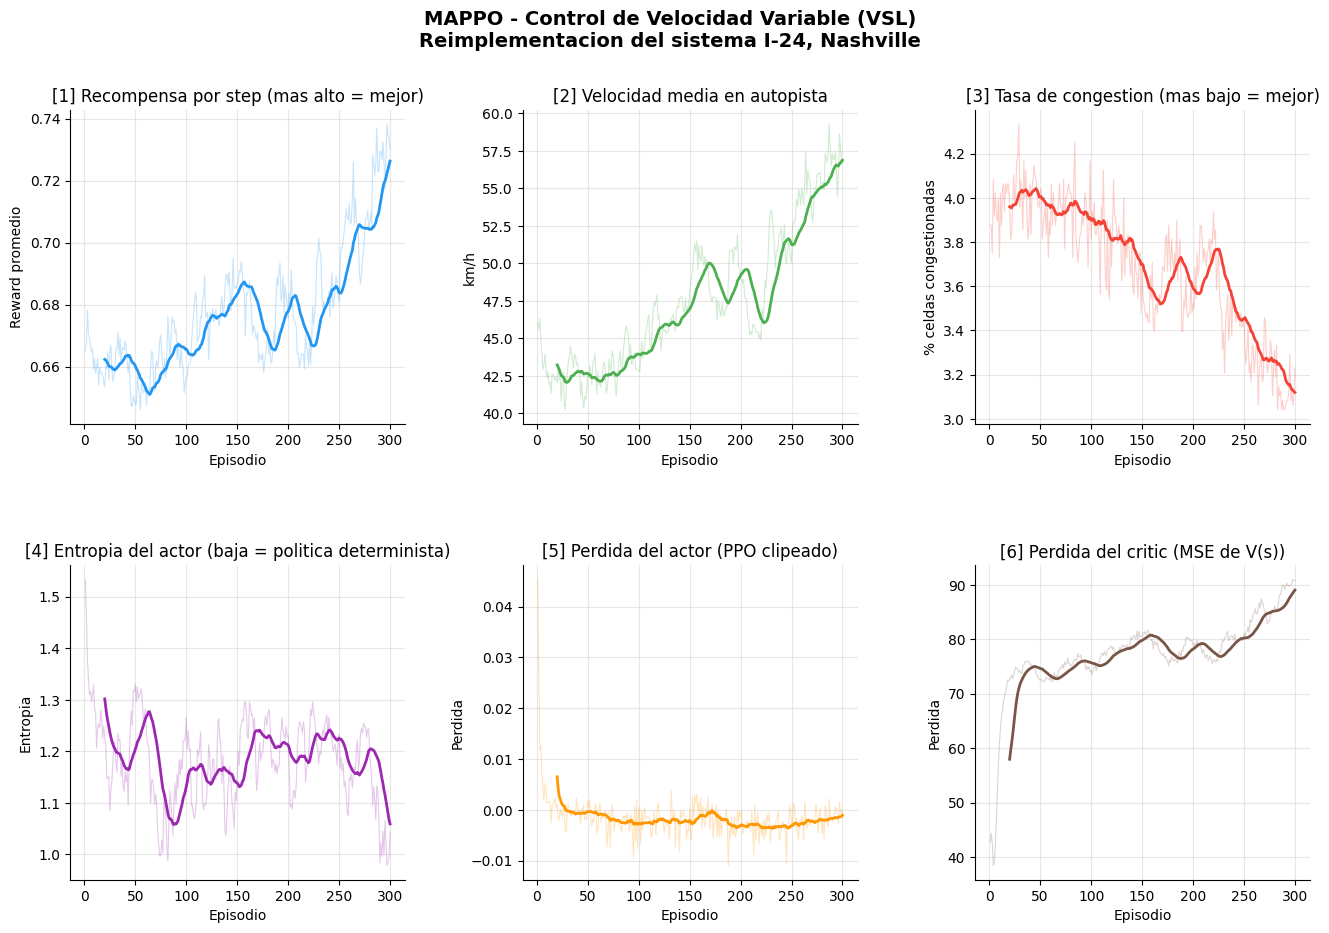

Grafica guardada en Drive


In [ ]:
def plot_training(history: dict, window: int = 20):
    """
    Visualiza las metricas de entrenamiento con suavizado.
    Produce el tipo de graficas que aparecen en papers de MARL.
    """
    def smooth(arr, w):
        if len(arr) < w:
            return arr
        kernel = np.ones(w) / w
        return np.convolve(arr, kernel, mode='valid')

    ep  = np.array(history['episode'])
    rew = np.array(history['reward'])
    spd = np.array(history['mean_speed'])
    cng = np.array(history['congestion_pct'])
    ent = np.array(history['entropy'])
    a_l = np.array(history['actor_loss'])
    c_l = np.array(history['critic_loss'])

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(
        'MAPPO - Control de Velocidad Variable (VSL)\n'
        'Reimplementacion del sistema I-24, Nashville',
        fontsize=14, fontweight='bold'
    )
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    def panel(ax, x, y, ylabel, color, title):
        ax.plot(x, y, alpha=0.25, color=color, linewidth=0.8)
        if len(y) >= window:
            x_s = x[window - 1:]
            ax.plot(x_s, smooth(y, window), color=color, linewidth=2)
        ax.set_xlabel('Episodio')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

    panel(fig.add_subplot(gs[0, 0]), ep, rew,
          'Reward promedio', '#2196F3',
          '[1] Recompensa por step (mas alto = mejor)')

    panel(fig.add_subplot(gs[0, 1]), ep, spd,
          'km/h', '#4CAF50',
          '[2] Velocidad media en autopista')

    panel(fig.add_subplot(gs[0, 2]), ep, cng,
          '% celdas congestionadas', '#F44336',
          '[3] Tasa de congestion (mas bajo = mejor)')

    panel(fig.add_subplot(gs[1, 0]), ep, ent,
          'Entropia', '#9C27B0',
          '[4] Entropia del actor (baja = politica determinista)')

    panel(fig.add_subplot(gs[1, 1]), ep, a_l,
          'Perdida', '#FF9800',
          '[5] Perdida del actor (PPO clipeado)')

    panel(fig.add_subplot(gs[1, 2]), ep, c_l,
          'Perdida', '#795548',
          '[6] Perdida del critic (MSE de V(s))')

    plt.savefig(Path(CHECKPOINT_DIR) / 'training_curves.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Grafica guardada en Drive")


plot_training(training_history)


## Celda 12 — Evaluación del agente entrenado

Compara la política MARL aprendida contra dos baselines:
- **Sin control:** todos los límites al máximo (110 km/h) siempre
- **Control fijo:** límite uniforme de 70 km/h (típico de sistemas rule-based)


In [ ]:
def evaluate_policy(policy_fn, n_episodes=10, seed=100, label="Política"):
    """
    Evalúa una política durante n_episodes y retorna métricas promedio.
    policy_fn: función (obs_list, env) → actions (np.ndarray)
    """
    env_eval = HighwaySim(
        n_cells=CONFIG['n_cells'],
        n_agents=CONFIG['n_agents'],
        episode_steps=CONFIG['episode_steps'],
        seed=seed
    )
    metrics = collections.defaultdict(list)

    for ep in range(n_episodes):
        obs_list = env_eval.reset()
        ep_speed = []
        ep_cong  = []

        done = False
        while not done:
            actions = policy_fn(obs_list, env_eval)
            obs_list, _, done, info = env_eval.step(actions)
            ep_speed.append(info['mean_speed'])
            ep_cong.append(info['congestion'])

        metrics['mean_speed'].append(np.mean(ep_speed))
        metrics['congestion'].append(np.mean(ep_cong))

    ms  = np.mean(metrics['mean_speed'])
    cng = np.mean(metrics['congestion']) * 100
    print(f"  {label:<30} | Speed: {ms:6.1f} km/h | Congestión: {cng:5.1f}%")
    return metrics


# ── Cargar mejor modelo ────────────────────────────────────────
best_ckpt = torch.load(Path(CHECKPOINT_DIR) / "mappo_best.pt",
                        map_location=device, weights_only=False)
actor_eval = SharedActor(
    CONFIG['obs_dim'], CONFIG['n_actions'], CONFIG['actor_hidden']
).to(device)
actor_eval.load_state_dict(best_ckpt['actor'])
actor_eval.eval()
print(f"✓ Modelo cargado (entrenado hasta ep {best_ckpt['episode']})")
print()

# ── Definir políticas de comparación ──────────────────────────
def policy_marl(obs_list, env):
    """Política MARL aprendida (determinista: argmax)."""
    obs_t = torch.tensor(np.array(obs_list),
                         dtype=torch.float32).to(device)
    masks = compute_invalid_action_masks(env.vsl_limits,
                                          CONFIG['n_actions']).to(device)
    with torch.no_grad():
        logits = actor_eval(obs_t)
        logits = logits.masked_fill(masks, float('-inf'))
        actions = logits.argmax(dim=-1)
    return actions.cpu().numpy()

def policy_no_control(obs_list, env):
    """Sin control: siempre máxima velocidad (acción 4 = 110 km/h)."""
    return np.full(CONFIG['n_agents'], 4, dtype=int)

def policy_fixed_70(obs_list, env):
    """Control fijo: siempre 70 km/h (acción 2)."""
    return np.full(CONFIG['n_agents'], 2, dtype=int)

# ── Comparar ───────────────────────────────────────────────────
print("=" * 65)
print("EVALUACIÓN COMPARATIVA (10 episodios, semilla diferente al entrenamiento)")
print("=" * 65)
m_marl   = evaluate_policy(policy_marl,       label="MARL (nuestro modelo)")
m_noctl  = evaluate_policy(policy_no_control, label="Sin control (110 km/h siempre)")
m_fixed  = evaluate_policy(policy_fixed_70,   label="Control fijo (70 km/h siempre)")
print("=" * 65)

# Mejora relativa
spd_marl  = np.mean(m_marl['mean_speed'])
spd_noctl = np.mean(m_noctl['mean_speed'])
spd_fixed = np.mean(m_fixed['mean_speed'])
cng_marl  = np.mean(m_marl['congestion']) * 100
cng_noctl = np.mean(m_noctl['congestion']) * 100

print(f"\n Mejora de velocidad vs sin control: {(spd_marl - spd_noctl)/spd_noctl*100:+.1f}%")
print(f" Reducción de congestión vs sin control: {(cng_noctl - cng_marl):+.1f} puntos porcentuales")


✓ Modelo cargado (entrenado hasta ep 297)

EVALUACIÓN COMPARATIVA (10 episodios, semilla diferente al entrenamiento)
  MARL (nuestro modelo)          | Speed:   66.6 km/h | Congestión:   2.7%
  Sin control (110 km/h siempre) | Speed:   83.3 km/h | Congestión:   2.6%
  Control fijo (70 km/h siempre) | Speed:   67.8 km/h | Congestión:   2.7%

 Mejora de velocidad vs sin control: -20.0%
 Reducción de congestión vs sin control: -0.1 puntos porcentuales


## Celda 13 — Diagrama espacio-temporal

El diagrama espacio-tiempo (time-space diagram) es la visualización estándar
en ingeniería de tráfico. Es exactamente la Figura 6 del paper I-24.
Los colores representan velocidad: **rojo = congestión**, **verde = flujo libre**.


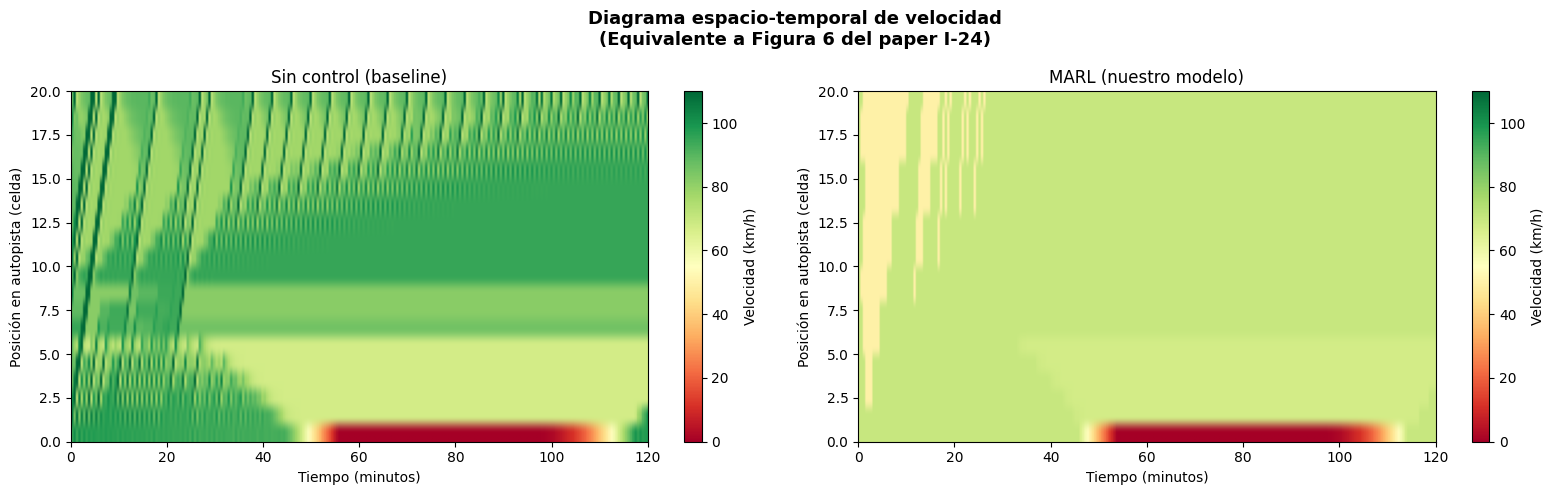

✓ Diagrama guardado en Drive

Interpretación:
  Zonas rojas = congestión (velocidad < 40 km/h)
  El MARL aprende a reducir el límite ANTES de que llegue la congestión
  (onda de slow-down preventiva → menos accidentes en cadena)


In [ ]:
def run_and_record(policy_fn, seed=200):
    """Corre un episodio y guarda el mapa de velocidades (tiempo × celda)."""
    env_rec = HighwaySim(
        n_cells       = CONFIG['n_cells'],
        n_agents      = CONFIG['n_agents'],
        episode_steps = CONFIG['episode_steps'],
        seed          = seed,
    )
    obs_list = env_rec.reset()
    speed_map_rec = []
    vsl_map_rec   = []

    done = False
    while not done:
        actions  = policy_fn(obs_list, env_rec)
        obs_list, _, done, info = env_rec.step(actions)

        v_lim = env_rec._build_speed_map()
        speeds_cell = env_rec._cell_speeds(v_lim)
        speed_map_rec.append(speeds_cell.copy())
        vsl_map_rec.append(v_lim.copy())

    return np.array(speed_map_rec), np.array(vsl_map_rec)


speed_marl,  vsl_marl  = run_and_record(policy_marl)
speed_noctl, vsl_noctl = run_and_record(policy_no_control)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Diagrama espacio-temporal de velocidad\n'
             '(Equivalente a Figura 6 del paper I-24)',
             fontsize=13, fontweight='bold')

for ax, data, title in [
    (axes[0], speed_noctl, 'Sin control (baseline)'),
    (axes[1], speed_marl,  'MARL (nuestro modelo)'),
]:
    im = ax.imshow(data.T, aspect='auto', origin='lower',
                   cmap='RdYlGn', vmin=0, vmax=110,
                   extent=[0, CONFIG['episode_steps'] * 30 / 60,
                           0, CONFIG['n_cells']])
    ax.set_xlabel('Tiempo (minutos)')
    ax.set_ylabel('Posición en autopista (celda)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='Velocidad (km/h)')

plt.tight_layout()
plt.savefig(Path(CHECKPOINT_DIR) / 'spacetime_diagram.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Diagrama guardado en Drive")
print()
print("Interpretación:")
print("  Zonas rojas = congestión (velocidad < 40 km/h)")
print("  El MARL aprende a reducir el límite ANTES de que llegue la congestión")
print("  (onda de slow-down preventiva implica => menos accidentes en cadena)")


## Celda 14 — Diferencias con el sistema real (y cómo cerrarlas)

Esta sección es importante para entender qué falta para ir a producción.

| Componente | Este cuaderno | Sistema real I-24 |
|---|---|---|
| **Simulador** | CTM macroscópico (NumPy) | TransModeler microscópico |
| **Agentes** | 8 (entrenamiento) | 67 (deployment) |
| **Observaciones** | Sintéticas del CTM | Sensores radar RDS físicos |
| **Paso de tiempo** | 30s (igual) | 30s ✓ |
| **Acciones** | {30,50,70,90,110} km/h | {30,40,50,60,70} mph |
| **Invalid masking** | Implementado ✓ | Implementado ✓ |
| **Safety guards** | Corrección post-masking | Speed-matching + debounce |
| **Deploy** | Inferencia local | AI-DSS → SmartWay CS → gantries |

### ¿Cómo escalar de 8 a 67 agentes?

Gracias al **parameter sharing**, los pesos entrenados con 8 agentes
funcionan directamente con 67. Esto es exactamente lo que hizo el equipo
de Vanderbilt: entrenaron con 8 agentes y desplegaron con 34/67.

### Próximos pasos reales
1. Reemplazar CTM por SUMO con red de I-24 (datos públicos en i24motion.org)
2. Agregar speed-matching guard (Ecuación 4 del paper)
3. Agregar debounce guard (Ecuación 6 del paper)
4. Validar open-loop con datos reales de RDS antes de cerrar el loop


In [ ]:
# ── Demostración: transferencia de 8 a N agentes ──────────────
print("Demostración de transferencia de parámetros (8 => N agentes)")
print("=" * 55)

for n_test in [8, 16, 34, 67]:
    env_test = HighwaySim(n_cells=n_test * 2, n_agents=n_test, seed=0)
    obs_t = torch.tensor(
        np.array(env_test.reset()), dtype=torch.float32
    ).to(device)

    with torch.no_grad():
        actions = actor_eval(obs_t).argmax(dim=-1)

    speeds = [f"{HighwaySim.SPEED_MAP[a]:.0f}" for a in actions.tolist()[:5]]
    print(f"  {n_test:2d} agentes → primeras 5 acciones: {speeds} km/h  ✓")

print()
print("Los MISMOS pesos funcionan para cualquier número de agentes.")
print("Esto es la ventaja del parameter sharing.")
print()
print("Código del sistema real en I-24:")
print("  https://github.com/Lab-Work/marl-vsl-controller")
print()
print("Paper completo:")
print("  https://arxiv.org/abs/2503.01017")


Demostración de transferencia de parámetros (8 → N agentes)
   8 agentes → primeras 5 acciones: ['70', '70', '70', '70', '70'] km/h  ✓
  16 agentes → primeras 5 acciones: ['70', '70', '70', '70', '70'] km/h  ✓
  34 agentes → primeras 5 acciones: ['70', '70', '70', '70', '70'] km/h  ✓
  67 agentes → primeras 5 acciones: ['70', '70', '70', '70', '70'] km/h  ✓

Los MISMOS pesos funcionan para cualquier número de agentes.
Esto es la ventaja del parameter sharing.

Código del sistema real en I-24:
  https://github.com/Lab-Work/marl-vsl-controller

Paper completo:
  https://arxiv.org/abs/2503.01017
